In [93]:
import numpy as np

p1_High = np.loadtxt('./data/P1_HighRelevance.csv', delimiter=',')
p1_Low = np.loadtxt('./data/P1_LowRelevance.csv', delimiter=',')
epn_HighNeg = np.loadtxt('./data/EPN_HighNegative.csv', delimiter=',')
epn_HighPos =  np.loadtxt('./data/EPN_HighPositive.csv', delimiter=',')
epn_HighNeu =  np.loadtxt('./data/EPN_HighNeutral.csv', delimiter=',')
epn_LowNeg = np.loadtxt('./data/EPN_LowNegative.csv', delimiter=',')
epn_LowPos = np.loadtxt('./data/EPN_LowPositive.csv', delimiter=',')
epn_LowNeu = np.loadtxt('./data/EPN_LowNeutral.csv', delimiter=',')
lpc_High = np.loadtxt('./data/LPC_HighRelevance.csv', delimiter=',')
lpc_Low = np.loadtxt('./data/LPC_LowRelevance.csv', delimiter=',')

In [ ]:
# P1: 73 to 120 ms
p1_High_filtered = p1_High[(p1_High[:, 0] >= 80) & (p1_High[:, 0] <= 120)]
p1_Low_filtered = p1_Low[(p1_Low[:, 0] >= 80) & (p1_Low[:, 0] <= 120)]

# EPN: 290 to 320 ms & 360 to 500
epn_HighNeg_filtered = epn_HighNeg[((epn_HighNeg[:, 0] >= 290) & (epn_HighNeg[:, 0] <= 320))|((epn_HighNeg[:, 0] >= 360) & (epn_HighNeg[:, 0] <= 500))]
epn_HighPos_filtered = epn_HighPos[((epn_HighPos[:, 0] >= 290) & (epn_HighPos[:, 0] <= 320))|((epn_HighPos[:, 0] >= 360) & (epn_HighPos[:, 0] <= 500))]
epn_LowNeg_filtered = epn_LowNeg[((epn_LowNeg[:, 0] >= 290) & (epn_LowNeg[:, 0] <= 320))|((epn_LowNeg[:, 0] >= 360) & (epn_LowNeg[:, 0] <= 500))]
epn_LowPos_filtered = epn_LowPos[((epn_LowPos[:, 0] >= 290) & (epn_LowPos[:, 0] <= 320))|((epn_LowPos[:, 0] >= 360) & (epn_LowPos[:, 0] <= 500))]

# LPC: 450 to 560 ms
lpc_High_filtered = lpc_High[(lpc_High[:, 0] >= 450) & (lpc_High[:, 0] <= 560)]
lpc_Low_filtered = lpc_Low[(lpc_Low[:, 0] >= 450) & (lpc_Low[:, 0] <= 560)]

# Result
print("P1 High shape:", p1_High_filtered.shape)
print("P1 Low shape:", p1_Low_filtered.shape)
print("EPN HighNeg shape:", epn_HighNeg_filtered.shape)
print("EPN HighPos shape:", epn_HighPos_filtered.shape)
print("EPN LowNeg shape:", epn_LowNeg_filtered.shape)
print("EPN LowPos shape:", epn_LowPos_filtered.shape)
print("LPC High shape:", lpc_High_filtered.shape)
print("LPC Low shape:", lpc_Low_filtered.shape)


P1 High shape: (30, 2)
P1 Low shape: (31, 2)
EPN HighNeg shape: (26, 2)
EPN HighPos shape: (33, 2)
EPN LowNeg shape: (44, 2)
EPN LowPos shape: (61, 2)
LPC High shape: (31, 2)
LPC Low shape: (31, 2)


In [ ]:
import numpy as np

def sort_by_x(data):
    """ascending order"""
    return data[np.argsort(data[:, 0])]

def downsample_uniformly(data, target_n):
    """to make equal number of samples"""
    if len(data) <= target_n:
        return data
    indices = np.linspace(0, len(data) - 1, target_n, dtype=int)
    return data[indices]

p1_High_sorted = sort_by_x(p1_High_filtered)
p1_Low_sorted = sort_by_x(p1_Low_filtered)
epn_HighNeg_sorted = sort_by_x(epn_HighNeg_filtered)
epn_HighPos_sorted = sort_by_x(epn_HighPos_filtered)
epn_LowNeg_sorted = sort_by_x(epn_LowNeg_filtered)
epn_LowPos_sorted = sort_by_x(epn_LowPos_filtered)
lpc_High_sorted = sort_by_x(lpc_High_filtered)
lpc_Low_sorted = sort_by_x(lpc_Low_filtered)


epn_LowNeg_sorted = downsample_uniformly(epn_LowNeg_sorted, 26)
epn_LowPos_sorted = downsample_uniformly(epn_LowPos_sorted, 33)



print("P1 High shape:", p1_High_sorted.shape)
print("P1 Low shape:", p1_Low_sorted.shape)
print("EPN HighNeg shape:", epn_HighNeg_sorted.shape)
print("EPN HighPos shape(after downsampling):", epn_HighPos_sorted.shape)
print("EPN LowNeg shape (after downsampling):", epn_LowNeg_sorted.shape)
print("EPN LowPos shape (after downsampling):", epn_LowPos_sorted.shape)
print("LPC High shape:", lpc_High_sorted.shape)
print("LPC Low shape:", lpc_Low_sorted.shape)


P1 High shape: (30, 2)
P1 Low shape: (31, 2)
EPN HighNeg shape: (26, 2)
EPN HighPos shape(after downsampling): (33, 2)
EPN LowNeg shape (after downsampling): (26, 2)
EPN LowPos shape (after downsampling): (33, 2)
LPC High shape: (31, 2)
LPC Low shape: (31, 2)


In [96]:
p1_area_high = np.trapz(p1_High_sorted[:, 1], p1_High_sorted[:, 0])
p1_area_low = np.trapz(p1_Low_sorted[:, 1], p1_Low_sorted[:, 0])

epn_area_highneg = np.trapz(epn_HighNeg_sorted[:, 1], epn_HighNeg_sorted[:, 0])
epn_area_highpos = np.trapz(epn_HighPos_sorted[:, 1], epn_HighPos_sorted[:, 0])
epn_area_lowneg = np.trapz(epn_LowNeg_sorted[:, 1], epn_LowNeg_sorted[:, 0])
epn_area_lowpos = np.trapz(epn_LowPos_sorted[:, 1], epn_LowPos_sorted[:, 0])
lpc_area_high = np.trapz(lpc_High_sorted[:, 1], lpc_High_sorted[:, 0])
lpc_area_low = np.trapz(lpc_Low_sorted[:, 1], lpc_Low_sorted[:, 0])


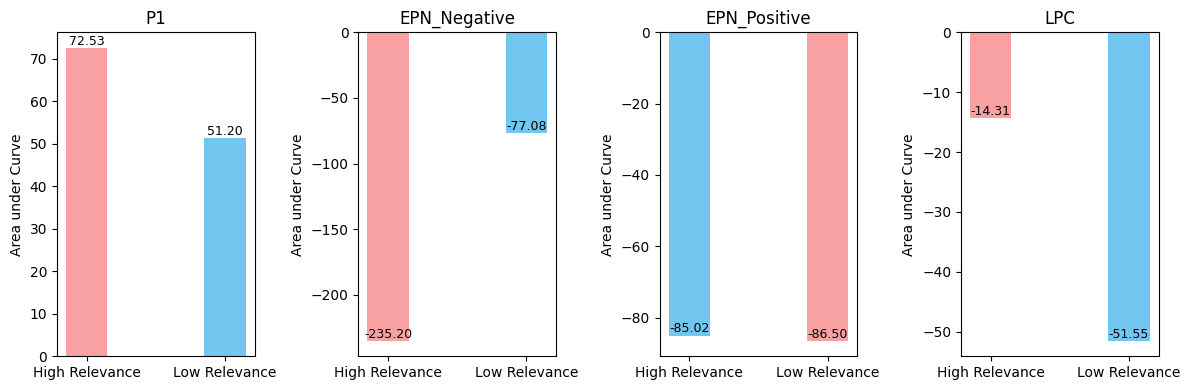

In [97]:
# Re-import libraries after code execution state reset
import numpy as np
import matplotlib.pyplot as plt

# Define hex colors
pink_rgb = "#f7a1a2"
blue_rgb = "#73c6f0"

# Compute area under the curve using trapezoidal integration
p1_High_area = np.trapz(p1_High_sorted[:, 1], p1_High_sorted[:, 0])
p1_Low_area = np.trapz(p1_Low_sorted[:, 1], p1_Low_sorted[:, 0])
epn_HighNeg_area = np.trapz(epn_HighNeg_sorted[:, 1], epn_HighNeg_sorted[:, 0])
epn_LowNeg_area = np.trapz(epn_LowNeg_sorted[:, 1], epn_LowNeg_sorted[:, 0])
epn_HighPos_area = np.trapz(epn_HighPos_sorted[:, 1], epn_HighPos_sorted[:, 0])
epn_LowPos_area = np.trapz(epn_LowPos_sorted[:, 1], epn_LowPos_sorted[:, 0])
lpc_High_area = np.trapz(lpc_High_sorted[:, 1], lpc_High_sorted[:, 0])
lpc_Low_area = np.trapz(lpc_Low_sorted[:, 1], lpc_Low_sorted[:, 0])

# Data grouping for integration plot (neutral removed)
titles = ['P1', 'EPN_Negative', 'EPN_Positive', 'LPC']
high_areas = [p1_High_area, epn_HighNeg_area, epn_HighPos_area, lpc_High_area]
low_areas = [p1_Low_area, epn_LowNeg_area, epn_LowPos_area, lpc_Low_area]

# Determine bar colors
colors_high, colors_low = [], []
for i, title in enumerate(titles):
    if title in ['P1', 'LPC']:
        if high_areas[i] >= low_areas[i]:
            colors_high.append(pink_rgb)
            colors_low.append(blue_rgb)
        else:
            colors_high.append(blue_rgb)
            colors_low.append(pink_rgb)
    else:
        if high_areas[i] <= low_areas[i]:
            colors_high.append(pink_rgb)
            colors_low.append(blue_rgb)
        else:
            colors_high.append(blue_rgb)
            colors_low.append(pink_rgb)

# Plotting bar chart for integration areas
fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i in range(4):
    ax = axes[i]
    x_pos = np.array([0, 1])
    bar_width = 0.3
    bars = ax.bar(
        x_pos,
        [high_areas[i], low_areas[i]],
        width=bar_width,
        color=[colors_high[i], colors_low[i]]
    )
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['High Relevance', 'Low Relevance'])
    ax.set_title(titles[i])
    ax.set_ylabel('Area under Curve')

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
